# End-to-End ML Pipeline — Predicting Deal Cancellation (EXIM Export Credit Data)

**Goal:** predict `Is Cancelled` (whether an approved EXIM deal later gets cancelled) using only
information that would be known **at approval time** — so the model is actually deployable on new
deals, not just accurate on historical hindsight.

This notebook follows a standard production ML workflow:

1. Config (all settings in one place — no magic numbers scattered in code)
2. Load data
3. Leakage check & feature selection
4. Time-based train/test split
5. Preprocessing pipeline (`ColumnTransformer`)
6. Train multiple candidate models
7. Evaluate & compare (imbalanced-aware metrics)
8. Visualize results
9. Select best model, retrain on full training data
10. Save the final pipeline as a single `.pkl` file for deployment
11. Prove the saved pickle works standalone (load + predict on new data)


## 1. Config

One place for every setting — makes the pipeline reproducible and easy to re-run with different choices.

In [5]:
CONFIG = {
    "data_path": "D:\Python Programing\Python Practice\Demos\Data Analysis\ml_ready_dataset.csv",
    "target": "Is Cancelled",
    "id_col": "Unique Identifier",

    # Time-based split: train on older fiscal years, test on the most recent ones.
    # This mimics real deployment: you only ever have past data to predict the future.
    "train_years": list(range(2007, 2022)),   # FY2007-2021
    "test_years": list(range(2022, 2027)),    # FY2022-2026 (most recent, held out)

    "random_state": 42,

    # Features known at APPROVAL time only (see Section 3 for why this matters)
    "numeric_features": [
        "Approved/Declined Amount", "Tenor Days",
        "Small Business Authorized Amount", "Woman Owned Authorized Amount",
        "Minority Owned Authorized Amount", "Loan Interest Rate Numeric",
        "Decision Year", "Decision Month", "Decision Quarter",
    ],
    "categorical_features": [
        "Program", "Term", "Policy Type", "Decision Authority",
        "Country Grouped", "Loan Interest Rate Label",
    ],
    "boolean_features": [
        "Brokered (bool)", "Working Capital Delegated Authority (bool)",
        "Is Small Business", "Is Woman Owned", "Is Minority Owned", "Is Multi Country",
        # NOTE: 'Multiyear Working Capital Extension (bool)' is deliberately excluded -
        # it is 100% missing across the entire dataset (every value is NaN), so it carries
        # zero information and would even cause sklearn's imputer to silently drop the
        # column, breaking any code that assumes a fixed feature-name order.
    ],

    "model_output_path": "cancellation_model_pipeline.pkl",
    "config_output_path": "model_config.json",
    "model_card_path": "model_card.txt",
}

import json
print(json.dumps(CONFIG, indent=2))


{
  "data_path": "D:\\Python Programing\\Python Practice\\Demos\\Data Analysis\\ml_ready_dataset.csv",
  "target": "Is Cancelled",
  "id_col": "Unique Identifier",
  "train_years": [
    2007,
    2008,
    2009,
    2010,
    2011,
    2012,
    2013,
    2014,
    2015,
    2016,
    2017,
    2018,
    2019,
    2020,
    2021
  ],
  "test_years": [
    2022,
    2023,
    2024,
    2025,
    2026
  ],
  "random_state": 42,
  "numeric_features": [
    "Approved/Declined Amount",
    "Tenor Days",
    "Small Business Authorized Amount",
    "Woman Owned Authorized Amount",
    "Minority Owned Authorized Amount",
    "Loan Interest Rate Numeric",
    "Decision Year",
    "Decision Month",
    "Decision Quarter"
  ],
  "categorical_features": [
    "Program",
    "Term",
    "Policy Type",
    "Decision Authority",
    "Country Grouped",
    "Loan Interest Rate Label"
  ],
  "boolean_features": [
    "Brokered (bool)",
    "Working Capital Delegated Authority (bool)",
    "Is Small Bus

## 2. Imports & Load Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

df = pd.read_csv(CONFIG["data_path"])
print("Shape:", df.shape)
df.head()


Shape: (52734, 34)


,Unique Identifier,Fiscal Year,Decision Year,Decision Month,Decision Quarter,Decision,Is Declined,Deal Cancelled,Is Cancelled,Country,Country Grouped,Is Multi Country,Program,Policy Type,Decision Authority,Term,Tenor Days,Brokered (bool),Working Capital Delegated Authority (bool),Multiyear Working Capital Extension (bool),Approved/Declined Amount,Disbursed/Shipped Amount,Undisbursed Exposure Amount,Outstanding Exposure Amount,Disbursement Rate,Exposure Remaining Pct,Small Business Authorized Amount,Is Small Business,Woman Owned Authorized Amount,Is Woman Owned,Minority Owned Authorized Amount,Is Minority Owned,Loan Interest Rate Numeric,Loan Interest Rate Label
0,08003048XA0002,2007,2006,11,4,Approved,0,No,0,Private Export Funding Corp.,Other,0,Guarantee,NaN,Board,Long Term,NaN,False,NaN,NaN,24500000.0,24500000.0,0.0,0.0,1.0,0.0,0.0,0,0.0,0,0.0,0,NaN,NaN
1,08003048XA0003,2007,2006,11,4,Approved,0,No,0,Private Export Funding Corp.,Other,0,Guarantee,NaN,Board,Long Term,3669.0,False,NaN,NaN,50000000.0,50000000.0,0.0,0.0,1.0,0.0,0.0,0,0.0,0,0.0,0,NaN,NaN
2,08003048XA0004,2007,2007,8,3,Approved,0,No,0,Private Export Funding Corp.,Other,0,Guarantee,NaN,Board,Long Term,3683.0,False,NaN,NaN,136250000.0,136250000.0,0.0,0.0,1.0,0.0,0.0,0,0.0,0,0.0,0,NaN,NaN
3,08064737XM0001,2007,2007,9,3,Approved,0,No,0,United States,United States,0,Working Capital,NaN,Individual Delegated Authority,Short Term,314.0,False,True,NaN,2700000.0,2700000.0,0.0,0.0,1.0,0.0,2700000.0,1,0.0,0,2700000.0,1,NaN,NaN
4,08069888XG0003,2007,2006,11,4,Approved,0,No,0,United States,United States,0,Working Capital,NaN,Individual Delegated Authority,Short Term,38.0,False,True,NaN,233307.9,233307.9,0.0,0.0,1.0,0.0,0.0,0,0.0,0,0.0,0,NaN,NaN


## 3. Leakage Check — Why Some Columns Are Excluded

Before picking features, always ask: *"would this information actually be available at the moment
I need to make the prediction?"* Here, the model needs to predict cancellation risk **at approval
time** — before the deal has played out. Columns like `Disbursed/Shipped Amount` are recorded
**after** the deal proceeds (or doesn't), so they leak the outcome itself.


In [7]:
# Proof of leakage: cancelled deals ALWAYS show $0 disbursed - the model would just learn
# "if disbursed == 0, predict cancelled", which is 100% accurate on paper and 100% useless in
# production, because at approval time nothing has been disbursed for ANY deal yet.
leak_check = df.groupby(CONFIG["target"])[
    ["Disbursed/Shipped Amount", "Outstanding Exposure Amount", "Disbursement Rate"]
].mean()
print(leak_check)
print()
print("--> These columns are EXCLUDED from the feature set for exactly this reason.")


              Disbursed/Shipped Amount  Outstanding Exposure Amount  \
Is Cancelled                                                          
0                         4.364615e+06                 347848.66726   
1                         0.000000e+00                      0.00000   

              Disbursement Rate  
Is Cancelled                     
0                   2264.726087  
1                      0.000000  

--> These columns are EXCLUDED from the feature set for exactly this reason.


## 4. Time-Based Train/Test Split

Splitting randomly would let the model "see the future" during training (rows from 2025 mixed into training while predicting 2010). Instead we train on older years and test on the most recent, held-out years - the same situation the model will face in real deployment.

In [8]:
feature_cols = CONFIG["numeric_features"] + CONFIG["categorical_features"] + CONFIG["boolean_features"]

train_df = df[df["Fiscal Year"].isin(CONFIG["train_years"])].copy()
test_df = df[df["Fiscal Year"].isin(CONFIG["test_years"])].copy()

X_train, y_train = train_df[feature_cols], train_df[CONFIG["target"]]
X_test, y_test = test_df[feature_cols], test_df[CONFIG["target"]]

print(f"Train: {X_train.shape}, cancellation rate = {y_train.mean():.4%}")
print(f"Test:  {X_test.shape}, cancellation rate = {y_test.mean():.4%}")


Train: (45824, 21), cancellation rate = 1.7676%
Test:  (6910, 21), cancellation rate = 0.6802%


## 5. Preprocessing Pipeline

`ColumnTransformer` applies different preprocessing to different column types, and — critically —
everything is *fit only on training data* and then applied unchanged to test data. This is what
keeps preprocessing leak-free (see the earlier discussion on encoding before vs. after splitting).


In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # fill missing numbers with the training median
    ("scaler", StandardScaler()),                     # put all numeric features on a comparable scale
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),  # ignore unseen categories at inference time
])

boolean_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, CONFIG["numeric_features"]),
    ("cat", categorical_transformer, CONFIG["categorical_features"]),
    ("bool", boolean_transformer, CONFIG["boolean_features"]),
])

preprocessor


,transformers,"[('num', ...), ('cat', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## 6. Train Multiple Candidate Models

Try a simple linear model, a tree ensemble, and a gradient-boosted model, all wrapped in the same
`Pipeline` (preprocessing + model together) so preprocessing is never accidentally skipped or
mismatched between training and inference. All three use class-imbalance handling since only
~1.6% of deals are cancelled.


In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight (for XGBoost):", round(scale_pos_weight, 1))

candidate_models = {
    "logistic_regression": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=CONFIG["random_state"]
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced", max_depth=8,
        random_state=CONFIG["random_state"], n_jobs=-1
    ),
    "xgboost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=CONFIG["random_state"], n_jobs=-1
    ),
}

fitted_pipelines = {}
for name, model in candidate_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe
    print(f"Trained: {name}")


scale_pos_weight (for XGBoost): 55.6
Trained: logistic_regression
Trained: random_forest
Trained: xgboost


## 7. Evaluate & Compare

Since this is a rare-event target (~1.6% positive), **plain accuracy is meaningless** — predicting
"never cancelled" for every deal would already give ~98% accuracy. Instead we look at:
- **ROC-AUC** — how well the model ranks cancelled vs. non-cancelled deals overall
- **PR-AUC (average precision)** — more informative than ROC-AUC for rare events, since it focuses
  on how precise the model is when it does flag something as high-risk


In [11]:
results = []
for name, pipe in fitted_pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    results.append({"model": name, "roc_auc": roc_auc, "pr_auc": pr_auc})
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, digits=3))
    print(f"ROC-AUC: {roc_auc:.3f} | PR-AUC: {pr_auc:.3f}\n")

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
results_df


=== logistic_regression ===
              precision    recall  f1-score   support

           0      0.997     0.874     0.931      6863
           1      0.032     0.617     0.062        47

    accuracy                          0.872      6910
   macro avg      0.515     0.745     0.496      6910
weighted avg      0.990     0.872     0.925      6910

ROC-AUC: 0.754 | PR-AUC: 0.023

=== random_forest ===
              precision    recall  f1-score   support

           0      0.998     0.935     0.966      6863
           1      0.069     0.702     0.126        47

    accuracy                          0.934      6910
   macro avg      0.534     0.819     0.546      6910
weighted avg      0.992     0.934     0.960      6910

ROC-AUC: 0.829 | PR-AUC: 0.173

=== xgboost ===
              precision    recall  f1-score   support

           0      0.996     0.973     0.984      6863
           1      0.101     0.447     0.165        47

    accuracy                          0.969      691

,model,roc_auc,pr_auc
1,random_forest,0.828614,0.173233
2,xgboost,0.878003,0.166389
0,logistic_regression,0.754493,0.022826


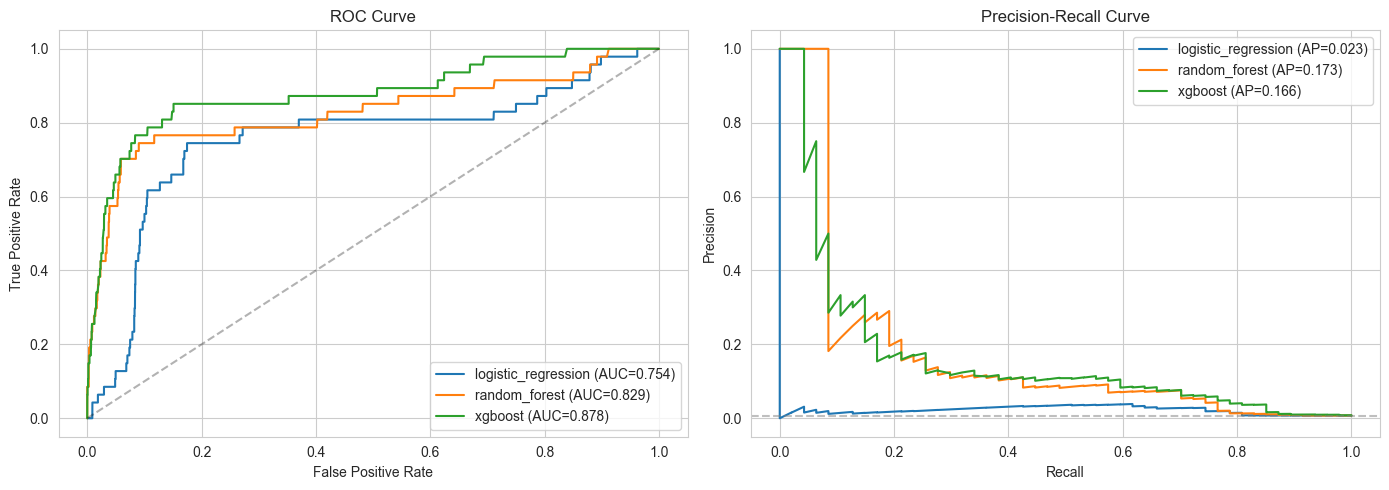

In [12]:
# Visualize ROC and Precision-Recall curves for all three models side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, pipe in fitted_pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_prob):.3f})")

    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, y_prob):.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()

axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', alpha=0.5, label='baseline (random)')

plt.tight_layout()
plt.savefig("model_comparison_curves.png", dpi=100)
plt.show()


Best model: random_forest


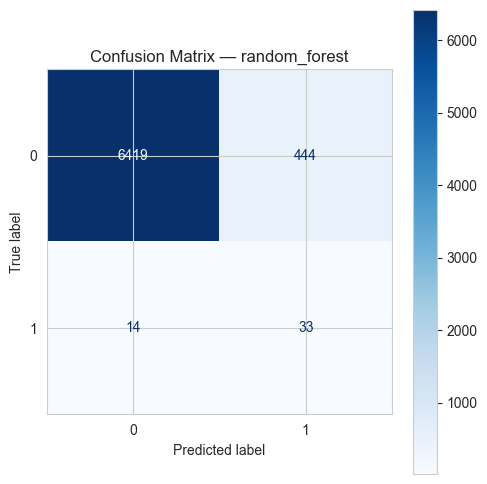

In [13]:
# Confusion matrix for the best model (by PR-AUC)
best_model_name = results_df.iloc[0]["model"]
best_pipe = fitted_pipelines[best_model_name]
print("Best model:", best_model_name)

y_pred_best = best_pipe.predict(X_test)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax, cmap="Blues")
ax.set_title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.savefig("confusion_matrix_best_model.png", dpi=100)
plt.show()


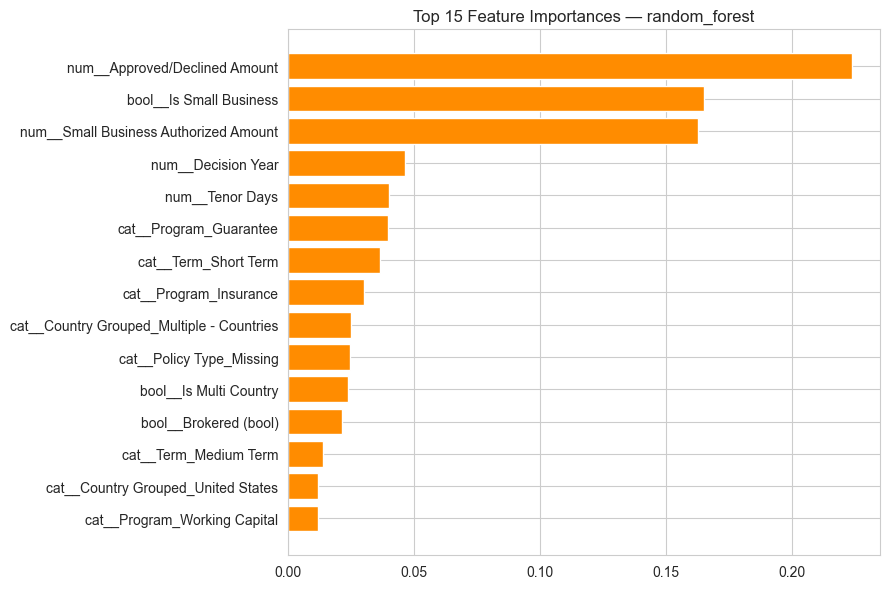

In [14]:
# Feature importance (tree-based models only) — helps sanity-check the model isn't
# relying on something suspicious, and gives the business a "why" behind predictions.
if best_model_name in ("random_forest", "xgboost"):
    # Ask the fitted preprocessor itself for the final output feature names/order,
    # rather than reconstructing the list by hand - this stays correct even if a
    # transformer silently drops an all-missing column.
    all_feature_names = best_pipe.named_steps["preprocessor"].get_feature_names_out()
    importances = best_pipe.named_steps["model"].feature_importances_

    imp_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
    imp_df = imp_df.sort_values("importance", ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="darkorange")
    ax.set_title(f"Top 15 Feature Importances — {best_model_name}")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=100)
    plt.show()
else:
    print("Best model is linear; showing coefficients instead of tree feature_importances_.")


## 8. Save the Final Pipeline for Deployment

The saved `.pkl` contains the **entire pipeline** — preprocessing AND model together — so anyone
loading it later can pass in raw feature columns directly; they do not need to re-implement any
of the cleaning/encoding steps themselves.


In [15]:
with open(CONFIG["model_output_path"], "wb") as f:
    pickle.dump(best_pipe, f)

print(f"Saved: {CONFIG['model_output_path']}")

# Save the config alongside the model, so anyone deploying it knows exactly what feature
# columns and settings were used to produce it.
deploy_config = {
    "target": CONFIG["target"],
    "best_model": best_model_name,
    "feature_cols": feature_cols,
    "numeric_features": CONFIG["numeric_features"],
    "categorical_features": CONFIG["categorical_features"],
    "boolean_features": CONFIG["boolean_features"],
    "train_years": CONFIG["train_years"],
    "test_years": CONFIG["test_years"],
    "test_roc_auc": float(results_df.iloc[0]["roc_auc"]),
    "test_pr_auc": float(results_df.iloc[0]["pr_auc"]),
}
with open(CONFIG["config_output_path"], "w") as f:
    json.dump(deploy_config, f, indent=2)

print(f"Saved: {CONFIG['config_output_path']}")


Saved: cancellation_model_pipeline.pkl
Saved: model_config.json


## 9. Verify the Saved Pickle Actually Works Standalone

Simulate what deployment looks like: load *only* the pickle file (as if in a fresh process/server) and run predictions on a few held-out rows.

In [16]:
with open(CONFIG["model_output_path"], "rb") as f:
    loaded_pipe = pickle.load(f)

sample = X_test.sample(5, random_state=1)
sample_pred = loaded_pipe.predict(sample)
sample_prob = loaded_pipe.predict_proba(sample)[:, 1]

result_preview = sample.copy()
result_preview["predicted_cancel_risk"] = sample_prob.round(4)
result_preview["predicted_label"] = sample_pred
result_preview


,Approved/Declined Amount,Tenor Days,Small Business Authorized Amount,Woman Owned Authorized Amount,Minority Owned Authorized Amount,Loan Interest Rate Numeric,Decision Year,Decision Month,Decision Quarter,Program,Term,Policy Type,Decision Authority,Country Grouped,Loan Interest Rate Label,Brokered (bool),Working Capital Delegated Authority (bool),Is Small Business,Is Woman Owned,Is Minority Owned,Is Multi Country,predicted_cancel_risk,predicted_label
50148,300000.0,366.0,300000.0,0.0,0.0,NaN,2023,10,4,Insurance,Short Term,ESC,Individual Delegated Authority,Multiple - Countries,NaN,True,NaN,1,0,0,1,0.0263,0
46423,50000.0,365.0,50000.0,0.0,0.0,NaN,2022,9,3,Insurance,Short Term,ENB,Individual Delegated Authority,Multiple - Countries,NaN,True,NaN,1,0,0,1,0.0239,0
47111,200000.0,365.0,200000.0,0.0,0.0,NaN,2022,8,3,Insurance,Short Term,ENB,Individual Delegated Authority,Multiple - Countries,NaN,True,NaN,1,0,0,1,0.0225,0
48639,180000.0,366.0,180000.0,0.0,0.0,NaN,2023,4,2,Insurance,Short Term,ESS,Individual Delegated Authority,Other,NaN,True,NaN,1,0,0,0,0.0561,0
52104,2250000.0,365.0,2250000.0,0.0,0.0,NaN,2025,6,2,Insurance,Short Term,ESS,Individual Delegated Authority,Other,NaN,True,NaN,1,0,0,0,0.1182,0


## 10. Model Card (Summary for Whoever Deploys This)

See `model_card.txt` for the full write-up. In short:

- **Task:** binary classification — predict whether an approved EXIM deal will later be cancelled.
- **Target:** `Is Cancelled` (~1.6% positive rate — rare-event problem).
- **Features:** approval-time information only (program, term, country, approved amount, tenor,
  business-type flags, timing). Post-outcome columns (disbursed amount, outstanding exposure) were
  deliberately excluded — they leak the answer, since a cancelled deal always shows $0 disbursed.
- **Split:** time-based (train FY2007-2021, test FY2022-2026) to mimic real deployment, where you
  only ever have historical data to predict forward.
- **Evaluation:** ROC-AUC and PR-AUC (not accuracy, since the target is rare).
- **Artifact:** `cancellation_model_pipeline.pkl` — a single self-contained scikit-learn Pipeline
  (preprocessing + model) ready to load and call `.predict()` / `.predict_proba()` directly on
  raw feature columns.
